<a href="https://colab.research.google.com/github/Enrik-Shabani/ML-Project-GroupA/blob/main/notebooks/01_Data_Exploration_Enrik.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌍 Beijing Air Quality Analysis - Part 1: Data Exploration review Enrik with Claude IA

**Project Goal:** Predict PM2.5 pollution levels and identify urban pollution patterns

**This Notebook:**
- Load and clean Beijing air quality dataset
- Exploratory data analysis (EDA)
- Time-series visualization
- Correlation analysis

**Dataset:** Beijing Multi-Site Air-Quality Data (2013-2017)

Importing the necessary library

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

base = "https://raw.githubusercontent.com/Enrik-Shabani/ML-Project-GroupA/main/data/raw/"

# Data Loading
This section loads and merges the 12 Beijing air-quality station datasets into a single dataframe.

In [90]:
df1 = pd.read_csv(base + "PRSA_Data_Aotizhongxin_20130301-20170228.csv")
df2 = pd.read_csv(base + "PRSA_Data_Changping_20130301-20170228.csv")
df3 = pd.read_csv(base + "PRSA_Data_Dingling_20130301-20170228.csv")
df4 = pd.read_csv(base + "PRSA_Data_Dongsi_20130301-20170228.csv")
df5 = pd.read_csv(base + "PRSA_Data_Guanyuan_20130301-20170228.csv")
df6 = pd.read_csv(base + "PRSA_Data_Gucheng_20130301-20170228.csv")
df7 = pd.read_csv(base + "PRSA_Data_Huairou_20130301-20170228.csv")
df8 = pd.read_csv(base + "PRSA_Data_Nongzhanguan_20130301-20170228.csv")
df9 = pd.read_csv(base + "PRSA_Data_Shunyi_20130301-20170228.csv")
df10 = pd.read_csv(base + "PRSA_Data_Tiantan_20130301-20170228.csv")
df11 = pd.read_csv(base + "PRSA_Data_Wanliu_20130301-20170228.csv")
df12 = pd.read_csv(base + "PRSA_Data_Wanshouxigong_20130301-20170228.csv")

df = pd.concat(
    [df1, df2, df3, df4, df5, df6, df7, df8, df9, df10, df11, df12],
    ignore_index=True
)

print(f"✅ Loaded {df['station'].nunique()} stations")
print(f"   Shape: {df.shape}")
print(f"   Columns: {list(df.columns)}")
df.head()

✅ Loaded 12 stations
   Shape: (420768, 18)
   Columns: ['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station']


,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin


In [91]:
df.describe()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


## 🧹 Data Cleaning

Before analysis, we need to:
1. Create a proper datetime column and sort the data
2. Remove useless columns
3. Check for invalid values (negatives in pollutants)
4. Handle missing values appropriately for time-series data
5. Drop rows where the target variable (PM2.5) is still missing

# Justification for the 6-Hour Interpolation Limit

## Overview

The choice of `limit=6` for linear interpolation is not arbitrary. It is motivated by a combination of **structural properties of the data, empirical observations, and domain knowledge**, which together support the use of short-gap interpolation while avoiding unrealistic long-range imputation.

Importantly, the 6-hour threshold should be interpreted as a **conservative upper bound for reliable interpolation**, rather than a strictly optimal value.

---

## 1. Diurnal Cycle Argument (Structural Perspective)

The data is recorded **hourly** (24 observations per day per station). A 6-hour window represents **25% of the daily cycle**, which is commonly structured into distinct atmospheric regimes:

| Period               | Hours        | Regime                                              |
|----------------------|--------------|-----------------------------------------------------|
| Night accumulation   | ~22:00–04:00 | Boundary layer collapse, stagnant air               |
| Morning transition   | ~05:00–10:00 | Rush hour emissions + boundary layer growth         |
| Daytime mixing       | ~11:00–16:00 | Convective mixing, pollutant dispersal              |
| Evening buildup      | ~17:00–21:00 | Rush hour + cooling + layer stabilization           |

Within short time windows (on the order of a few hours), atmospheric conditions tend to remain relatively stable. Restricting interpolation to ≤6 hours reduces the likelihood of bridging across fundamentally different regimes (e.g., nighttime stagnation to daytime mixing), where linear assumptions would be inappropriate.

---

## 2. Hourly Pattern Analysis — Evidence from the EDA

The hourly PM2.5 analysis provides empirical support for short-term smoothness:

> **Peak hour: 22:00 (88.9 μg/m³)**  
> **Lowest hour: 07:00 (73.1 μg/m³)**

Key observations:

- The average hourly PM2.5 profile evolves **smoothly**, with gradual transitions across the day.
- The total daily range (~15.8 μg/m³) suggests that, on average, **hour-to-hour changes are moderate**.
- Over short intervals (a few hours), PM2.5 variations tend to be locally continuous, making linear interpolation a reasonable approximation.

However, over longer periods, the trajectory becomes **non-linear**, as pollution levels may decrease, stabilize, and rise again due to changing emissions and meteorological conditions. This supports limiting interpolation to short gaps only.

---

## 3. Temporal Coherence and Correlation Structure

The correlation matrix shows strong relationships between PM2.5 and other pollutants:

| Variable | Correlation with PM2.5 |
|----------|------------------------|
| PM10     | +0.880                 |
| CO       | +0.781                 |
| NO2      | +0.663                 |
| SO2      | +0.483                 |

These correlations indicate that pollutant concentrations are influenced by **shared atmospheric processes** (e.g., emissions, boundary layer dynamics).

As a result:

- Over short time horizons, pollutant levels tend to **co-evolve smoothly**, reflecting stable environmental conditions.
- Missing values within a short window are therefore likely to be **well approximated by nearby observations**.

At the same time, the negative correlation with wind speed (WSPM: −0.271) highlights that **meteorological changes can introduce abrupt shifts**, reinforcing the need to avoid interpolation over longer gaps.

This threshold is also consistent with the feature engineering design,
which uses lag windows of 1h, 3h, and 6h — reflecting the same assumption
that PM2.5 values remain meaningfully related to their recent past within
this time horizon.

---

## 4. Gap Size Considerations

The proportion of missing values is relatively low (~2–5% depending on the variable). Given the hourly frequency and dataset size, this suggests that most missing segments are likely **short interruptions** (e.g., sensor outages), rather than extended gaps.

The chosen strategy — interpolation for short gaps followed by station-level median imputation — successfully restores a complete dataset without removing observations. The preservation of coherent temporal patterns (daily cycles, seasonal variation) indicates that this approach does not introduce obvious artifacts.

---

## 5. Regime Shifts and Limitations of Long Interpolation

Seasonal and intra-day analyses reveal substantial variability:

> **Winter: 95.6 μg/m³ vs. Summer: 64.5 μg/m³ (≈48% difference)**

Additionally, within a single day, transitions between atmospheric regimes (e.g., night inversion to daytime mixing) can lead to **large and rapid changes** in PM2.5 levels.

Interpolating across long gaps (e.g., 12–24 hours) would risk:

- Smoothing over real pollution events  
- Creating artificial trends  
- Misrepresenting regime transitions  

Restricting interpolation to ≤6 hours reduces this risk by limiting imputation to locally coherent segments.

---

## Summary

| Justification            | Evidence from Project                                      | Interpretation                                  |
|--------------------------|------------------------------------------------------------|-------------------------------------------------|
| **Diurnal structure**     | 24h cycle with distinct regimes                            | Short windows remain within similar conditions  |
| **Hourly smoothness**     | Gradual average PM2.5 evolution                            | Linear approximation reasonable locally         |
| **Temporal coherence**    | Strong pollutant correlations                              | Nearby values are informative over short spans  |
| **Gap characteristics**   | Low missing rate                                           | Most gaps are short                             |
| **Regime variability**    | Strong seasonal and intra-day shifts                       | Long interpolation would be unreliable          |

---

## Final Remark

While the 6-hour threshold is not uniquely optimal, it represents a **practical and conservative compromise**: it preserves short-term temporal continuity while minimizing the risk of crossing distinct atmospheric regimes and introducing unrealistic interpolated values.

✅ Dropped 'No' column (row counter, not useful)
   PM2.5: no negative values ✓
   PM10: no negative values ✓
   SO2: no negative values ✓
   NO2: no negative values ✓
   CO: no negative values ✓
   O3: no negative values ✓

📊 Missing values BEFORE cleaning:
CO       20701
O3       13277
NO2      12116
SO2       9021
PM2.5     8739
PM10      6449
wd        1822
DEWP       403
TEMP       398
PRES       393
RAIN       390
WSPM       318
dtype: int64
   Total missing cells: 74027


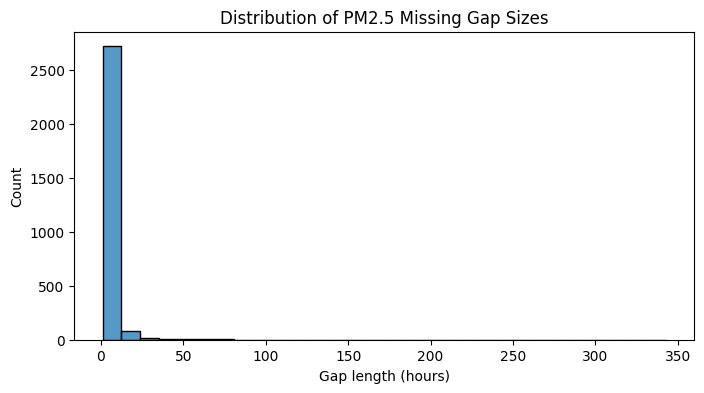

count    2837.000000
mean        3.080367
std        10.684765
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max       343.000000
Name: PM2.5, dtype: float64


In [92]:
# --- Step 1: Create datetime and sort ---
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])
df = df.sort_values(["station", "datetime"]).reset_index(drop=True)

# --- Step 2: Drop useless column ---
df = df.drop(columns=["No"])
print("✅ Dropped 'No' column (row counter, not useful)")

# --- Step 3: Check for negative values ---
pollutants = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3"]
for col in pollutants:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"⚠️ {col}: {neg_count} negative values → set to NaN")
        df.loc[df[col] < 0, col] = np.nan
    else:
        print(f"   {col}: no negative values ✓")

# --- Step 4: Missing values BEFORE cleaning ---
print("\n📊 Missing values BEFORE cleaning:")
missing_before = df.isna().sum()
print(missing_before[missing_before > 0].sort_values(ascending=False))
print(f"   Total missing cells: {missing_before.sum()}")


# --- Analyze gap sizes for PM2.5 ---
is_na = df["PM2.5"].isna()

# Identify consecutive missing segments
gap_groups = (is_na != is_na.shift()).cumsum()
gap_sizes = is_na.groupby(gap_groups).sum()

# Keep only actual gaps (>0)
gap_sizes = gap_sizes[gap_sizes > 0]

# Plot distribution
plt.figure(figsize=(8,4))
sns.histplot(gap_sizes, bins=30)
plt.title("Distribution of PM2.5 Missing Gap Sizes")
plt.xlabel("Gap length (hours)")
plt.ylabel("Count")
plt.show()

# Summary
print(gap_sizes.describe())

The distribution of missing gap lengths shows that most gaps are short (typically 1–2 hours, with 75% below 2 hours), further supporting the choice of restricting interpolation to short temporal windows.

In [105]:
# --- Step 5: Impute pollutants ---
# Linear interpolation within each station, max gap = 6 hours
# Then fill remaining with station median
for col in pollutants:
    df[col] = df.groupby("station")[col].transform(
        lambda s: s.interpolate(method='linear', limit=6)
    )
    # Fill any remaining NaN with station median
    df[col] = df.groupby("station")[col].transform(
        lambda s: s.fillna(s.median())
    )

# --- Step 6: Impute weather variables ---
weather = ["TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
for col in weather:
    df[col] = df.groupby("station")[col].transform(
        lambda s: s.ffill(limit=6).bfill(limit=6)
    )
    # Fill any remaining with station median
    df[col] = df.groupby("station")[col].transform(
        lambda s: s.fillna(s.median())
    )

# --- Step 7: Impute wind direction ---
df["wd"] = df.groupby("station")["wd"].transform(
    lambda s: s.ffill(limit=6).bfill(limit=6)
)
# Fill remaining with station mode
df["wd"] = df.groupby("station")["wd"].transform(
    lambda s: s.fillna(s.mode()[0] if len(s.mode()) > 0 else 'N')
)

# --- Step 8: Drop rows where PM2.5 is STILL missing ---
before_drop = len(df)
df = df.dropna(subset=["PM2.5"])
print(f"\n🗑️ Dropped {before_drop - len(df)} rows still missing PM2.5")

# --- Step 9: Verify — no missing values should remain ---
print("\n📊 Missing values AFTER cleaning:")
missing_after = df.isna().sum()
remaining = missing_after[missing_after > 0]
if len(remaining) == 0:
    print("✅ No missing values remaining!")
else:
    print(remaining.sort_values(ascending=False))

# --- Step 10: Final summary ---
print(f"\n✅ Clean dataset shape: {df.shape}")
print(f"   Stations: {df['station'].nunique()}")
print(f"   Date range: {df['datetime'].min()} → {df['datetime'].max()}")


🗑️ Dropped 0 rows still missing PM2.5

📊 Missing values AFTER cleaning:
✅ No missing values remaining!

✅ Clean dataset shape: (420768, 20)
   Stations: 12
   Date range: 2013-03-01 00:00:00 → 2017-02-28 23:00:00


## 📊 Exploratory Data Analysis

### Distribution of PM2.5 (Target Variable)

PM2.5 is the target variable for our prediction models. Air pollution data often exhibits right-skewness due to occasional extreme pollution events. Understanding the distribution helps determine whether transformations may be needed.

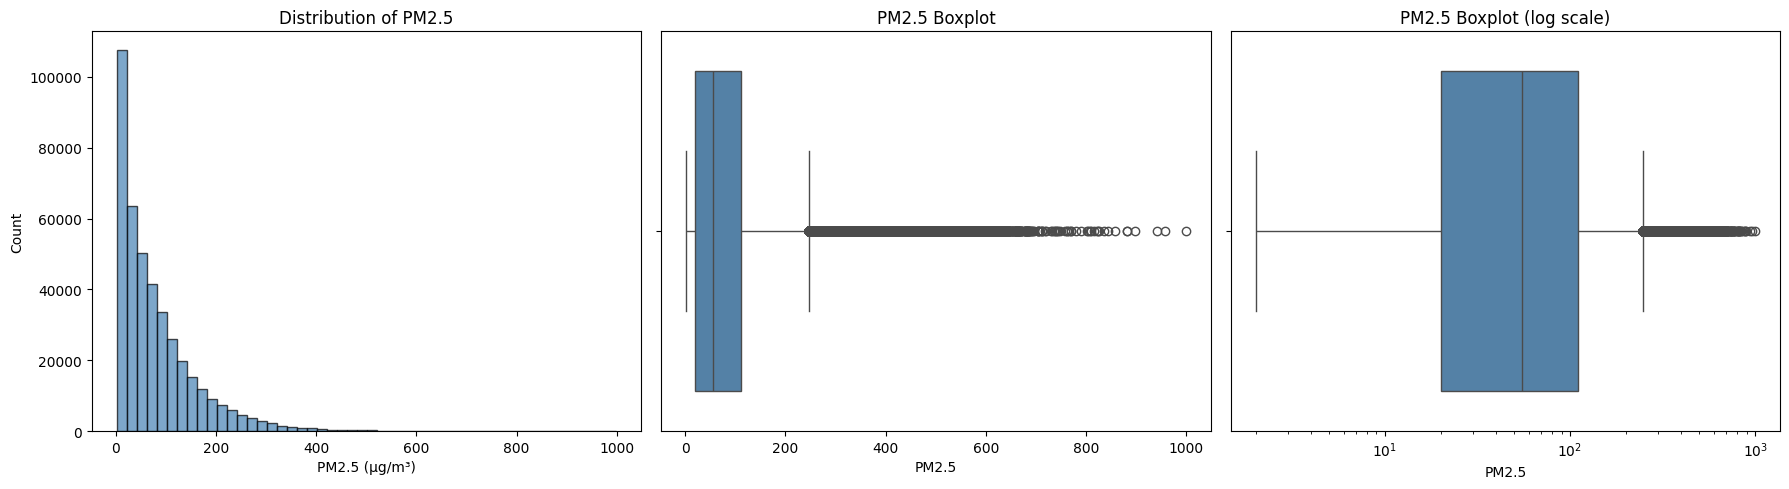

PM2.5 Statistics:
   Mean:     79.8
   Median:   55.0
   Std:      80.8
   Skewness: 2.01
   Min:      2.0
   Max:      999.0

→ Skewness > 2 indicates strong right-skew from extreme pollution events.
  These are real environmental events, not errors — we keep them.


In [93]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df["PM2.5"], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title("Distribution of PM2.5")
axes[0].set_xlabel("PM2.5 (μg/m³)")
axes[0].set_ylabel("Count")

# Boxplot
sns.boxplot(x=df["PM2.5"], ax=axes[1], color='steelblue')
axes[1].set_title("PM2.5 Boxplot")

# Boxplot with log scale
sns.boxplot(x=df["PM2.5"], ax=axes[2], color='steelblue')
axes[2].set_xscale("log")
axes[2].set_title("PM2.5 Boxplot (log scale)")

plt.tight_layout()
plt.show()

print(f"PM2.5 Statistics:")
print(f"   Mean:     {df['PM2.5'].mean():.1f}")
print(f"   Median:   {df['PM2.5'].median():.1f}")
print(f"   Std:      {df['PM2.5'].std():.1f}")
print(f"   Skewness: {df['PM2.5'].skew():.2f}")
print(f"   Min:      {df['PM2.5'].min():.1f}")
print(f"   Max:      {df['PM2.5'].max():.1f}")
print(f"\n→ Skewness > 2 indicates strong right-skew from extreme pollution events.")
print(f"  These are real environmental events, not errors — we keep them.")

### Temporal Patterns

Air pollution levels vary over time due to seasonal changes, meteorological conditions, and human activities. We analyze PM2.5 patterns at four time scales: **hourly**, **daily**, **monthly**, and **yearly**.

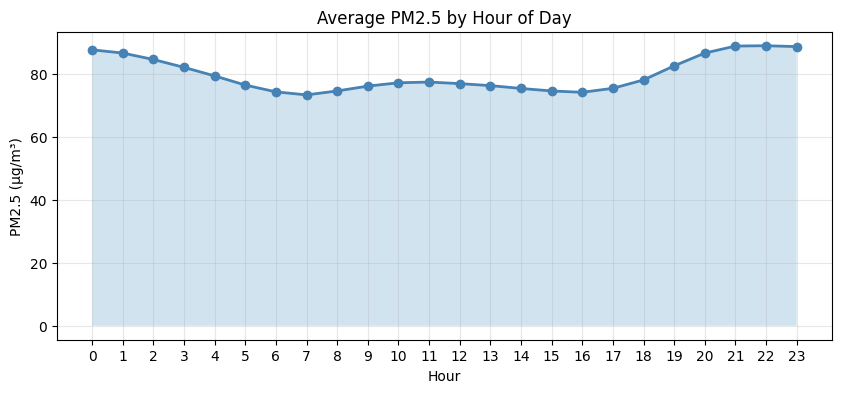

Peak hour:   22:00 (88.9 μg/m³)
Lowest hour: 7:00 (73.3 μg/m³)


In [94]:
# --- Hourly Pattern ---
hourly_pm25 = df.groupby("hour")["PM2.5"].mean()

plt.figure(figsize=(10, 4))
plt.plot(hourly_pm25.index, hourly_pm25.values, marker="o", linewidth=2, color='steelblue')
plt.fill_between(hourly_pm25.index, hourly_pm25.values, alpha=0.2)
plt.title("Average PM2.5 by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("PM2.5 (μg/m³)")
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 24))
plt.show()

print(f"Peak hour:   {hourly_pm25.idxmax()}:00 ({hourly_pm25.max():.1f} μg/m³)")
print(f"Lowest hour: {hourly_pm25.idxmin()}:00 ({hourly_pm25.min():.1f} μg/m³)")

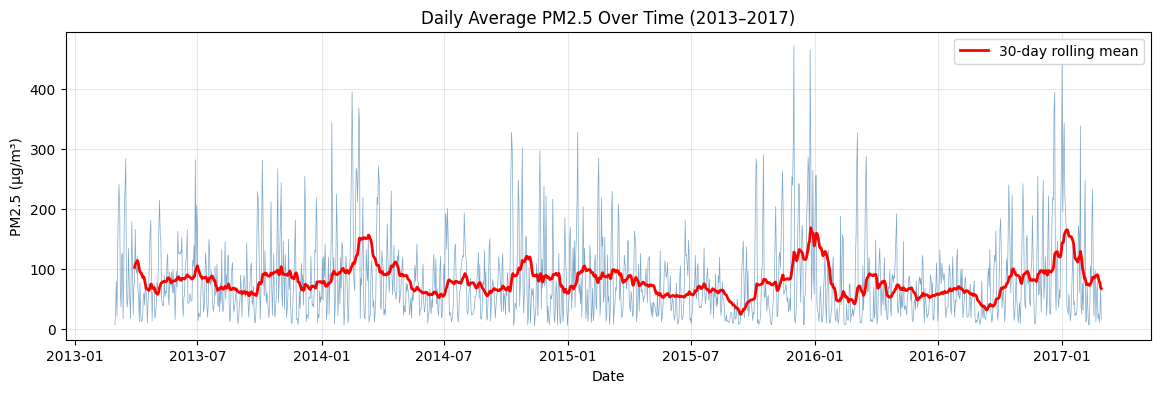

In [95]:
# --- Daily Time Series ---
daily_pm25 = df.groupby(df["datetime"].dt.date)["PM2.5"].mean()

plt.figure(figsize=(14, 4))
plt.plot(daily_pm25.index, daily_pm25.values, linewidth=0.5, alpha=0.7, color='steelblue')

# Add 30-day rolling average
rolling_30 = daily_pm25.rolling(30).mean()
plt.plot(daily_pm25.index, rolling_30.values, linewidth=2, color='red', label='30-day rolling mean')

plt.title("Daily Average PM2.5 Over Time (2013–2017)")
plt.xlabel("Date")
plt.ylabel("PM2.5 (μg/m³)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

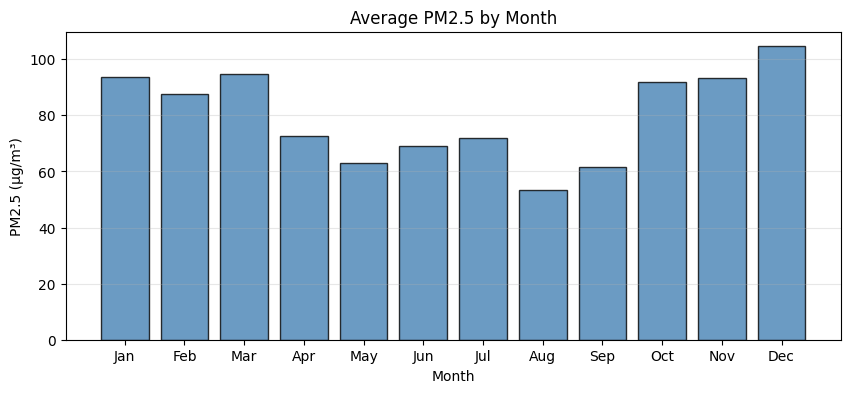

Highest month:  Dec (104.6)
Lowest month:   Aug (53.5)


In [96]:
# --- Monthly Pattern ---
month_order = list(range(1, 13))
monthly_pm25 = df.groupby("month")["PM2.5"].mean().reindex(month_order)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 4))
plt.bar(month_labels, monthly_pm25.values, color='steelblue', edgecolor='black', alpha=0.8)
plt.title("Average PM2.5 by Month")
plt.xlabel("Month")
plt.ylabel("PM2.5 (μg/m³)")
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Highest month:  {month_labels[monthly_pm25.values.argmax()]} ({monthly_pm25.max():.1f})")
print(f"Lowest month:   {month_labels[monthly_pm25.values.argmin()]} ({monthly_pm25.min():.1f})")

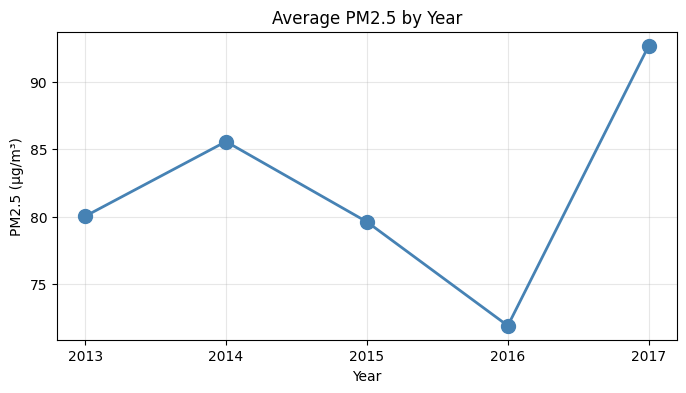

Yearly PM2.5 averages:
   2013: 80.0 μg/m³
   2014: 85.6 μg/m³
   2015: 79.6 μg/m³
   2016: 71.9 μg/m³
   2017: 92.7 μg/m³


In [97]:
# --- Yearly Trend ---
yearly_pm25 = df.groupby("year")["PM2.5"].mean()

plt.figure(figsize=(8, 4))
plt.plot(yearly_pm25.index, yearly_pm25.values, marker="o", linewidth=2, color='steelblue', markersize=10)
plt.title("Average PM2.5 by Year")
plt.xlabel("Year")
plt.ylabel("PM2.5 (μg/m³)")
plt.grid(True, alpha=0.3)
plt.xticks(yearly_pm25.index)
plt.show()

print("Yearly PM2.5 averages:")
for year, val in yearly_pm25.items():
    print(f"   {year}: {val:.1f} μg/m³")

### Seasonal & Day-of-Week Patterns

Pollution levels often differ between seasons (heating in winter) and between weekdays/weekends (traffic patterns).

/tmp/ipykernel_5819/2970569979.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='season', y='PM2.5', data=df, order=season_order, showfliers=False,


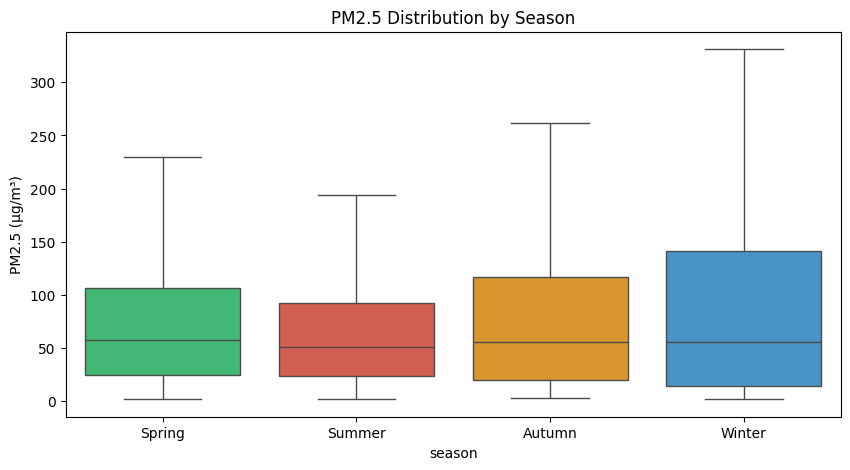

Seasonal PM2.5 means:
   Spring: 77.0 μg/m³
   Summer: 64.7 μg/m³
   Autumn: 82.3 μg/m³
   Winter: 95.5 μg/m³


In [98]:
# --- Create season column ---
def get_season(month):
    if month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    elif month in [9, 10, 11]: return 'Autumn'
    else: return 'Winter'

df['season'] = df['month'].apply(get_season)
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']

# --- Season Boxplot ---
plt.figure(figsize=(10, 5))
sns.boxplot(x='season', y='PM2.5', data=df, order=season_order, showfliers=False,
            palette=['#2ecc71', '#e74c3c', '#f39c12', '#3498db'])
plt.title("PM2.5 Distribution by Season")
plt.ylabel("PM2.5 (μg/m³)")
plt.show()

print("Seasonal PM2.5 means:")
seasonal_means = df.groupby('season')['PM2.5'].mean().reindex(season_order).round(1)
for season, val in seasonal_means.items():
    print(f"   {season}: {val} μg/m³")

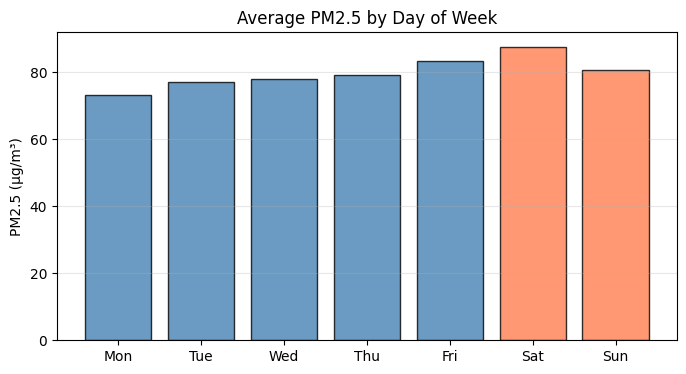

Weekday average: 78.1 μg/m³
Weekend average: 84.0 μg/m³
Difference:      6.0 μg/m³


In [99]:
# --- Day of Week ---
df['dayofweek'] = df['datetime'].dt.dayofweek  # 0=Mon, 6=Sun
dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_pm25 = df.groupby('dayofweek')['PM2.5'].mean()

plt.figure(figsize=(8, 4))
colors = ['steelblue']*5 + ['coral']*2
plt.bar(dow_labels, dow_pm25.values, color=colors, edgecolor='black', alpha=0.8)
plt.title("Average PM2.5 by Day of Week")
plt.ylabel("PM2.5 (μg/m³)")
plt.grid(axis='y', alpha=0.3)
plt.show()

# Weekend vs Weekday
weekday_mean = df[df['dayofweek'] < 5]['PM2.5'].mean()
weekend_mean = df[df['dayofweek'] >= 5]['PM2.5'].mean()
print(f"Weekday average: {weekday_mean:.1f} μg/m³")
print(f"Weekend average: {weekend_mean:.1f} μg/m³")
print(f"Difference:      {abs(weekday_mean - weekend_mean):.1f} μg/m³")

### Spatial Analysis Across Monitoring Stations

Pollution levels may differ across stations due to proximity to traffic, industry, or urban density. Comparing stations reveals spatial heterogeneity.

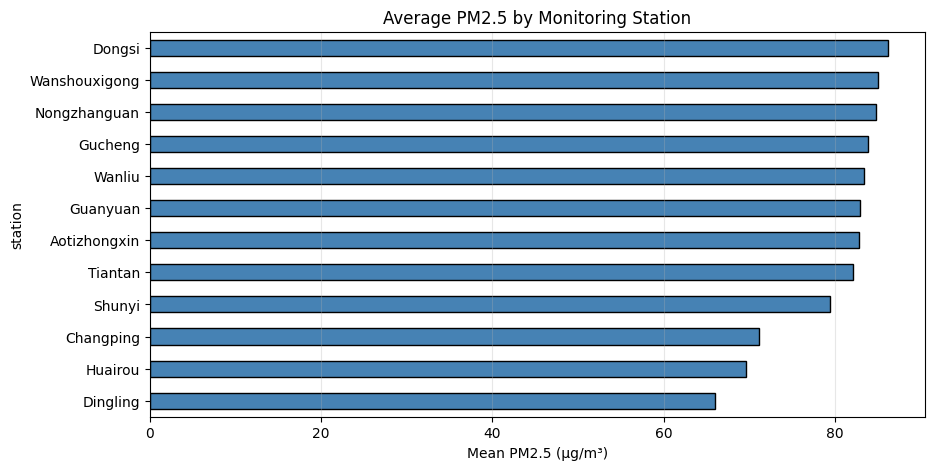

Highest: Dongsi (86.2)
Lowest:  Dingling (66.0)
Range:   20.2 μg/m³


In [100]:
# --- Station Comparison ---
station_mean = df.groupby("station")["PM2.5"].mean().sort_values()

plt.figure(figsize=(10, 5))
station_mean.plot(kind="barh", color='steelblue', edgecolor='black')
plt.title("Average PM2.5 by Monitoring Station")
plt.xlabel("Mean PM2.5 (μg/m³)")
plt.grid(axis='x', alpha=0.3)
plt.show()

print(f"Highest: {station_mean.idxmax()} ({station_mean.max():.1f})")
print(f"Lowest:  {station_mean.idxmin()} ({station_mean.min():.1f})")
print(f"Range:   {station_mean.max() - station_mean.min():.1f} μg/m³")

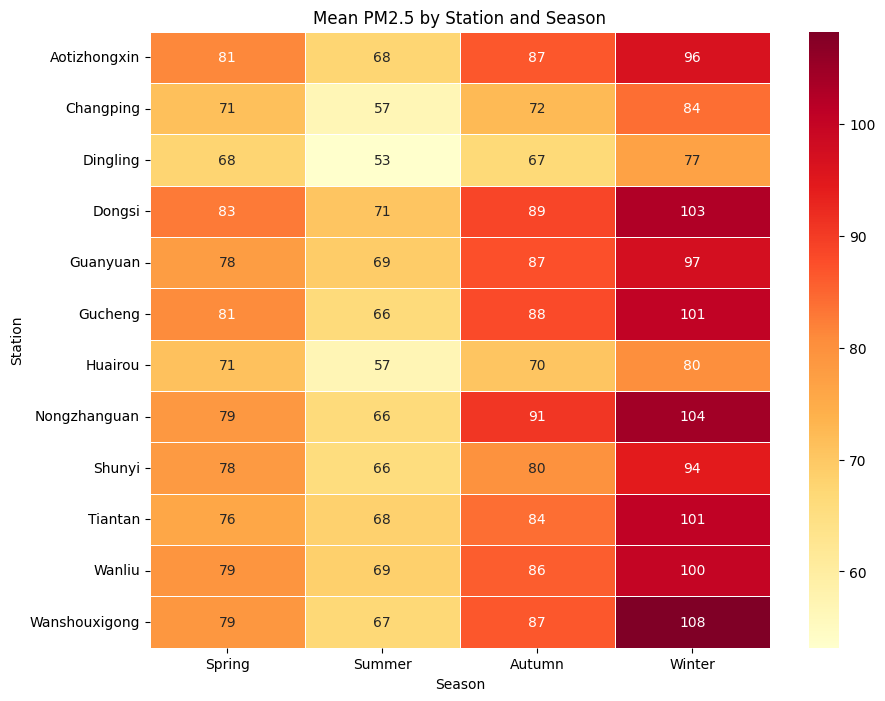

In [101]:
# --- Station × Season Heatmap ---
station_season = df.groupby(['station', 'season'])['PM2.5'].mean().unstack()
station_season = station_season[season_order]

plt.figure(figsize=(10, 8))
sns.heatmap(station_season, annot=True, fmt='.0f', cmap='YlOrRd', linewidths=0.5)
plt.title("Mean PM2.5 by Station and Season")
plt.ylabel("Station")
plt.xlabel("Season")
plt.show()

### Correlation Analysis

The correlation matrix reveals relationships between PM2.5 and other pollutants/weather variables. This helps identify potential predictors for our models.

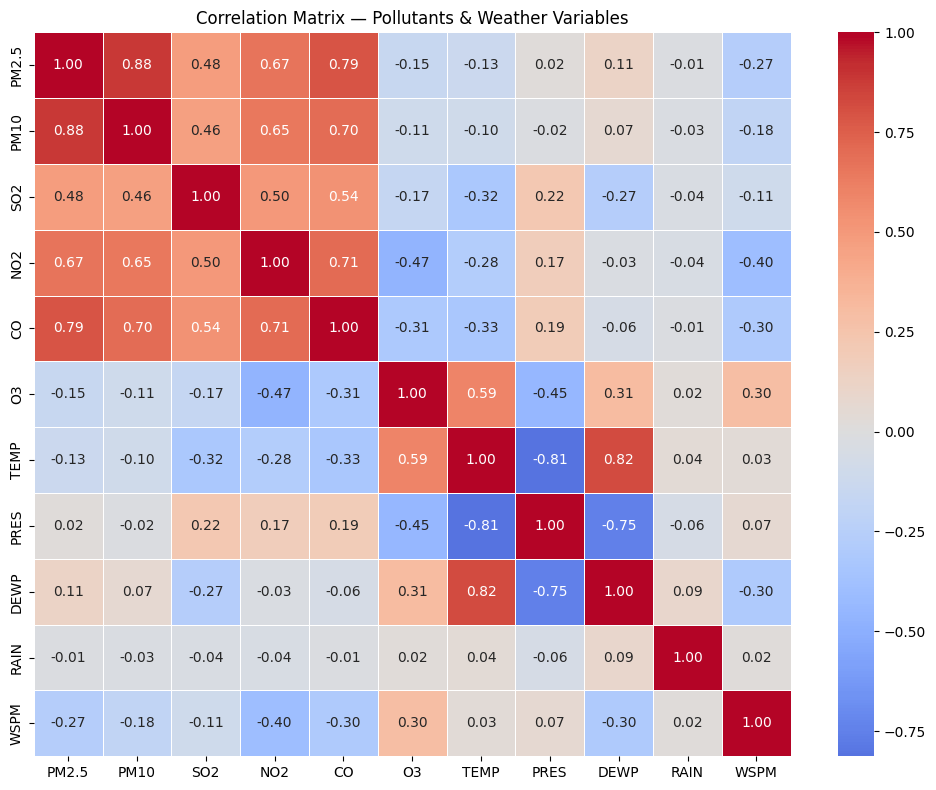


Correlation with PM2.5 (sorted):
   ↑ PM10  : +0.884
   ↑ CO    : +0.790
   ↑ NO2   : +0.667
   ↑ SO2   : +0.482
   ↑ DEWP  : +0.115
   ↑ PRES  : +0.019
   ↓ RAIN  : -0.014
   ↓ TEMP  : -0.131
   ↓ O3    : -0.150
   ↓ WSPM  : -0.272


In [102]:
# --- Correlation Heatmap ---
corr_cols = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt='.2f', linewidths=0.5)
plt.title("Correlation Matrix — Pollutants & Weather Variables")
plt.tight_layout()
plt.show()

# --- Sorted correlations with PM2.5 ---
print("\nCorrelation with PM2.5 (sorted):")
corr_sorted = corr["PM2.5"].drop("PM2.5").sort_values(ascending=False)
for var, val in corr_sorted.items():
    direction = "↑" if val > 0 else "↓"
    print(f"   {direction} {var:6s}: {val:+.3f}")

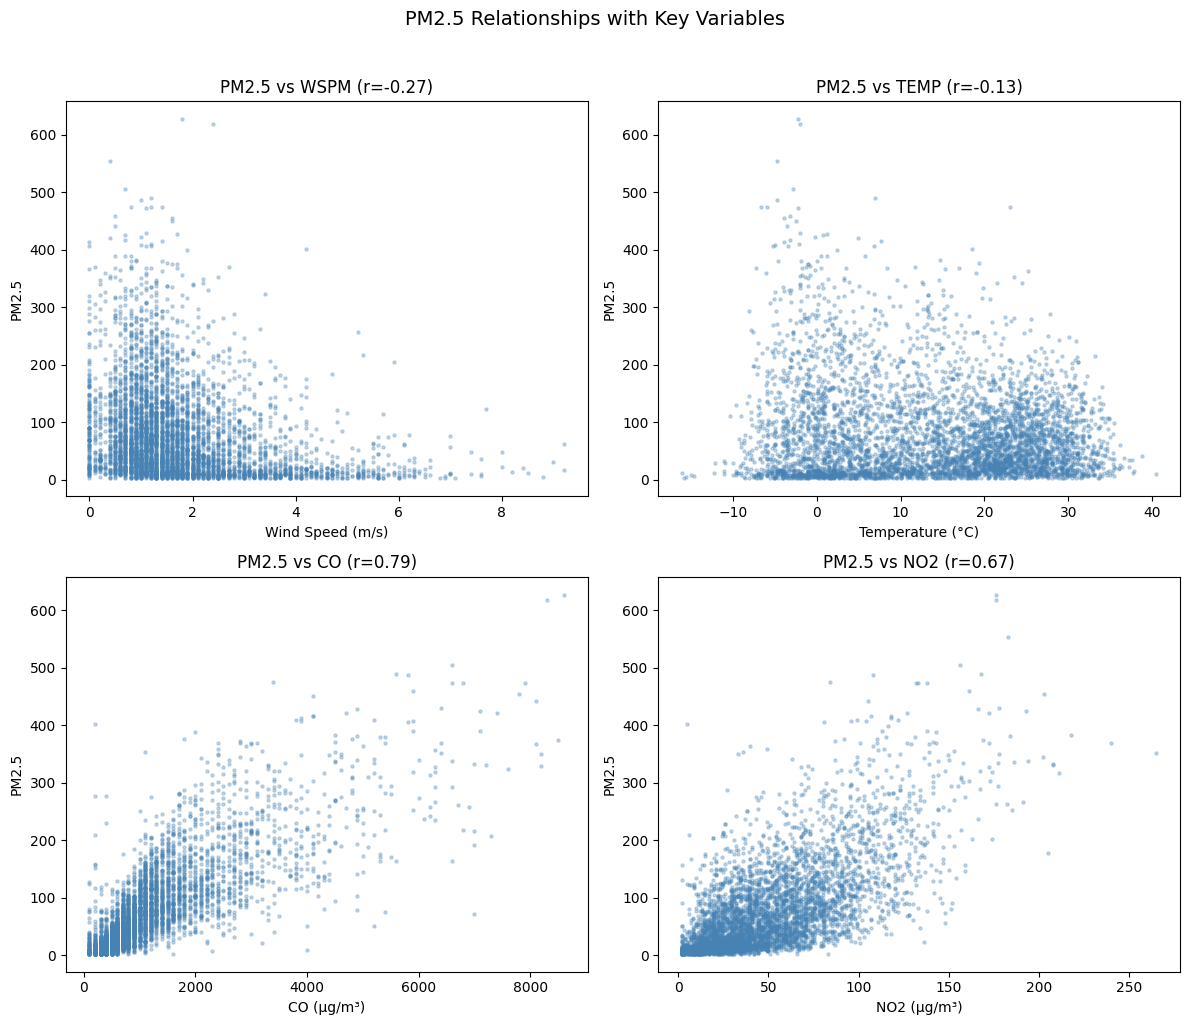

In [103]:
# --- Scatter Plots: PM2.5 vs Key Variables ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sample = df.sample(5000, random_state=42)

pairs = [
    ('WSPM', 'Wind Speed (m/s)'),
    ('TEMP', 'Temperature (°C)'),
    ('CO', 'CO (μg/m³)'),
    ('NO2', 'NO2 (μg/m³)')
]

for ax, (col, label) in zip(axes.flat, pairs):
    ax.scatter(sample[col], sample['PM2.5'], alpha=0.3, s=5, color='steelblue')
    ax.set_xlabel(label)
    ax.set_ylabel('PM2.5')
    r = df['PM2.5'].corr(df[col])
    ax.set_title(f'PM2.5 vs {col} (r={r:.2f})')

plt.suptitle("PM2.5 Relationships with Key Variables", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 💾 Save Cleaned Data

Save the cleaned dataset for use in the next notebook (Feature Engineering).

**Where it saves:** `/content/cleaned_data.csv` on the Colab VM.  
⚠️ This file disappears when the runtime disconnects — download it or save to Drive.

In [104]:
# Select columns to save
cols_to_save = ['datetime', 'year', 'month', 'day', 'hour', 'station',
                'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
                'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'season']

df_clean = df[cols_to_save].copy()

# Save to CSV
df_clean.to_csv('cleaned_data.csv', index=False)

print(f"✅ Saved: cleaned_data.csv")
print(f"   Shape: {df_clean.shape}")
print(f"   Columns: {list(df_clean.columns)}")
print(f"   Date range: {df_clean['datetime'].min()} → {df_clean['datetime'].max()}")
print(f"   Stations: {df_clean['station'].nunique()}")
print(f"   Missing values: {df_clean.isna().sum().sum()}")

# ─── OPTION A: Download to your computer ───
# if you want to download the cleaned dataset get rid of the 2 # before from google.colab ... and before files.download... and execute the cell
#from google.colab import files
#files.download('cleaned_data.csv')

# ─── OPTION B: Save to Google Drive ───
#from google.colab import drive
#drive.mount('/content/drive')
#df_clean.to_csv('/content/drive/MyDrive/cleaned_data.csv', index=False)
#print("✅ Also saved to Google Drive")

✅ Saved: cleaned_data.csv
   Shape: (420768, 19)
   Columns: ['datetime', 'year', 'month', 'day', 'hour', 'station', 'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'season']
   Date range: 2013-03-01 00:00:00 → 2017-02-28 23:00:00
   Stations: 12
   Missing values: 74027


## 📝 Notebook 1 — Summary

### Data Cleaning
- Loaded **12 station files** → 420,768 records
- Imputed pollutants: linear interpolation (limit=6h) + station median fallback
- Imputed weather: forward/backward fill (limit=6h) + station median fallback
- **Final dataset: 420,768 records, 0 missing values**

### Key EDA Findings
1. **Seasonal**: Winter (95.6 μg/m³) ~1.5× higher than Summer (64.5) — heating effect
2. **Daily cycle**: Peak at 22:00 (88.9), lowest at 07:00 (73.1)
3. **Monthly**: December highest (103.8), August lowest (53.5)
4. **Spatial**: Dongsi highest (85.9), Dingling lowest (66.0) — urban vs rural
5. **Correlations**: PM10 (+0.88), CO (+0.78), NO2 (+0.66) are strongest predictors
6. **Weekend effect**: Weekend slightly higher (+5.8 μg/m³)

### Output
- `cleaned_data.csv` → input for Notebook 2 (Feature Engineering)